<a href="https://colab.research.google.com/github/martynalacha/Computational-Intelligence-Labs/blob/main/MLP_Approximation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ReLu vs Tanh

The goal of this task is to design neural networks that approximate a sales function based on advertising expenditures. The evaluation and comparison of different architectures and activation functions should be carried out using Mean Squared Error (MSE).

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Shape: (200, 4)
Size: 800
Coulmns: Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')
Info
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB
Duplicates count: 0
Outliers count: 2

Architecture (80, 80, 80, 80, 80), activation = 'relu'
Score for training: 0.9917
Score for testing: 0.9794
MSE: 0.5921

Architecture (20, 20), activation = 'relu'
Score for training: 0.9759
Score for testing: 0.9656
MSE: 0.9900

Architecture (80, 80, 80, 80, 80), activation = 'tanh'
Score for training: 0.9836
Score for testing: 0.9850
MSE: 0.4319
Architecture (20,20), activation='tanh'


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Score for training: 0.7867
Score for testing: 0.7706
MSE: 6.5991


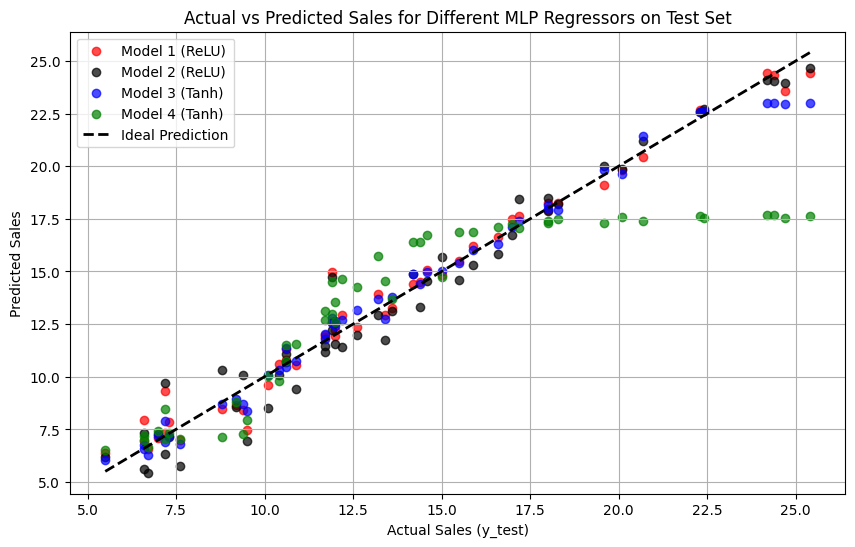

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# Load the dataset
df_adv = pd.read_csv('/content/sample_data/Advertising.csv', index_col=0)

# initial data analysis
display(df_adv.head())
print(f"Shape: {df_adv.shape}")
print(f"Size: {df_adv.size}")
print(f"Coulmns: {df_adv.columns}")
print("Info")
df_adv.info()
# None missing values

# Check for duplicates
print(f"Duplicates count: {df_adv.duplicated().sum()}")

# Outilers detection using Interquartile Range method
np_adv = np.array(df_adv)
Q1 = np.quantile(np_adv, 0.25, axis=0)
Q3 = np.quantile(np_adv, 0.75, axis=0)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_mask = (np_adv < lower_bound) | (np_adv > upper_bound)
print(f"Outliers count: {outliers_mask.sum()}")

np_adv = np_adv[~outliers_mask.any(axis=1)]

X = np_adv[:, : -1]
y = np_adv[:, -1]

# Split the dataset into training and testing sets (75/25 by default)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Standarize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Model 1: Deep architecture with ReLU ---
print(f"\nArchitecture (80, 80, 80, 80, 80), activation = 'relu'")
network1 = MLPRegressor(solver='adam',hidden_layer_sizes=(80, 80, 80, 80, 80), max_iter = 1000, tol = 0.001, activation = 'relu', random_state=42)
network1.fit(X_train, y_train)
pred1 = network1.predict(X_test)
print(f"Score for training: {network1.score(X_train, y_train):.4f}")
print(f"Score for testing: {network1.score(X_test, y_test):.4f}")
print(f"MSE: {np.mean((pred1 - y_test) ** 2):.4f}")

# --- Model 2: Shallow architecture with ReLU ---
print(f"\nArchitecture (20, 20), activation = 'relu'")
network2 = MLPRegressor(solver='adam', hidden_layer_sizes=(20, 20), max_iter=1000, tol=0.001, activation = 'relu', random_state=42)
network2.fit(X_train, y_train)
pred2 = network2.predict(X_test)
print(f"Score for training: {network2.score(X_train, y_train):.4f}")
print(f"Score for testing: {network2.score(X_test, y_test):.4f}")
print(f"MSE: {np.mean((pred2 - y_test) ** 2):.4f}")

# --- Model 3: Deep architecture with Tanh ---
print(f"\nArchitecture (80, 80, 80, 80, 80), activation = 'tanh'")
network3 = MLPRegressor(solver='adam', hidden_layer_sizes=(80,80,80,80,80), max_iter=1000, tol=0.001, activation='tanh', random_state=42)
network3.fit(X_train, y_train)
pred3 = network3.predict(X_test)
print(f"Score for training: {network3.score(X_train, y_train):.4f}")
print(f"Score for testing: {network3.score(X_test, y_test):.4f}")
print(f"MSE: {np.mean((pred3 - y_test)** 2):.4f}")

# --- Model 4: Shallow architecture with Tanh ---
print(f"Architecture (20,20), activation='tanh'")
network4 = MLPRegressor(solver='adam', hidden_layer_sizes=(20, 20), max_iter=1000, tol=0.001, activation='tanh', random_state=42)
network4.fit(X_train, y_train)
pred4 = network4.predict(X_test)
print(f"Score for training: {network4.score(X_train, y_train):.4f}")
print(f"Score for testing: {network4.score(X_test, y_test):.4f}")
print(f"MSE: {np.mean((pred4 - y_test) ** 2):.4f}")

# Plotting Actual vs Predicted for the test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred1, color='red', label='Model 1 (ReLU)', alpha=0.7)
plt.scatter(y_test, pred2, color='black', label='Model 2 (ReLU)', alpha=0.7)
plt.scatter(y_test, pred3, color='blue', label='Model 3 (Tanh)', alpha=0.7)
plt.scatter(y_test, pred4, color='green', label='Model 4 (Tanh)', alpha=0.7)

# Add an ideal prediction line (y_true = y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Prediction')
plt.xlabel('Actual Sales (y_test)')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales for Different MLP Regressors on Test Set')
plt.legend()
plt.grid(True)
plt.show()

**ConclusionsArchitecture Impact:**

Deep networks (5 layers, 80 neurons) significantly outperformed shallow ones (2 layers, 20 neurons). The shallow Tanh model failed to converge within 1000 epochs, proving insufficient for this problem.

**Activation Functions (ReLU vs Tanh):** ReLU provided high stability across all architectures, successfully avoiding the "dying ReLU" issue. While Tanh failed in the shallow network, it achieved the absolute best results when applied to the deep architecture.

**Generalization & Visual Assessment:** Model 3 (Deep, Tanh) demonstrated outstanding generalization with no overfitting (Test $R^2$ was slightly higher than Train $R^2$). On the scatter plot, its predictions aligned closest to the ideal $y=x$ line.

**Summary:**

The deep architecture (5x80) utilizing the Tanh activation function is the recommended model. It provides the optimal balance, achieving the lowest MSE (0.4319) and highest predictive precision

### MSE, MAPE, $R^2$

The diabetes dataset from sklearn.datasets was used to predict the progression of the disease based on patient features. The data were scaled to a common range and split into training and testing sets. Experiments were conducted using five different neural network architectures, and MSE, MAPE, and $R^2$
 metrics were calculated for each. For the best-performing model, a plot comparing actual and predicted values was created, and the impact of network architecture on approximation quality was analyzed to identify the smallest network achieving satisfactory results.

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log 

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(



Architecture: (8,)
MSE: 2887.0691 | MAPE: 0.3814 | R2: 0.4779 | R2 train: 0.5657


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(



Architecture: (64,)
MSE: 2967.3816 | MAPE: 0.3853 | R2: 0.4634 | R2 train: 0.6839


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(



Architecture: (32, 32)
MSE: 5316.3353 | MAPE: 0.5112 | R2: 0.0386 | R2 train: 0.9503

Architecture: (64, 32, 16)
MSE: 7047.4030 | MAPE: 0.5605 | R2: -0.2745 | R2 train: 0.9993

Architecture: (16, 16, 16, 16, 16)
MSE: 6328.0876 | MAPE: 0.4690 | R2: -0.1444 | R2 train: 0.9367


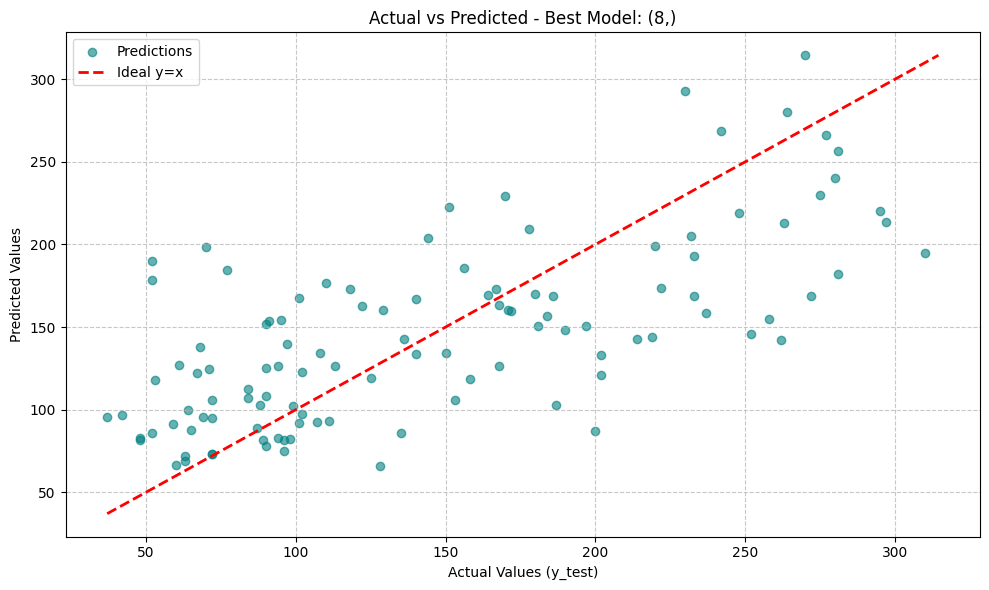

In [5]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt

# Load the dataset
dataset = load_diabetes()
print(dataset.keys())
print(dataset.DESCR)

# Create a DataFrame containing both features and the target variable to keep them aligned
df_diabetes = pd.DataFrame(dataset.data, columns=dataset.feature_names)

# Display initial data overview
print(df_diabetes.head())
print(f"\n\n Size of the dataset: {df_diabetes.size}")
print(f"Shape of the dataset: {df_diabetes.shape}")

# Handle duplicates and missing values
if df_diabetes.duplicated().sum() > 0:
  df_diabetes = df_diabetes.drop_duplicates()
  print(f"\nDuplicates removed")

if df_diabetes.isna().sum().sum() > 0:
  df_diabetes = df_diabetes.dropna()
  print(f"\nMissing values removed")

# Outliers analysis

# Extract features back to a numpy array for outlier analysis
np_diabetes = np.array(df_diabetes)

# Perform outlier detection using the Interquartile Range (IQR) method
Q1 = np.quantile(np_diabetes, 0.25, axis=0)
Q3 = np.quantile(np_diabetes, 0.75, axis=0)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_mask = (np_diabetes < lower_bound) | (np_diabetes > upper_bound)

# Count outliers but keep them in the dataset
print(f"\nOutliers count: {outlier_mask.sum()}")

X = np_diabetes
y = np.array(dataset.target)

# Split the dataset into training and testing sets with a fixed random state
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define network architectures to evaluate
architectures = [
    (8,),
    (64,),
    (32, 32),
    (64, 32, 16),
    (16, 16, 16, 16, 16)
]

results = []

# Train and evaluate models for each architecture
for a in architectures:
  network = MLPRegressor(hidden_layer_sizes=a, solver='adam', max_iter=5000, activation='relu', random_state=42)
  network.fit(X_train, y_train)
  pred = network.predict(X_test)
  r2_train = network.score(X_train, y_train)

  # Calculate metrics
  mse = mean_squared_error(y_test, pred)
  mape = mean_absolute_percentage_error(y_test, pred)
  r2 = network.score(X_test, y_test)

  results.append((a, mse, mape, r2, pred))

  print(f"\nArchitecture: {a}")
  print(f"MSE: {mse:.4f} | MAPE: {mape:.4f} | R2: {r2:.4f} | R2 train: {r2_train:.4f}")


# Extract the architecture with the best results (assuming the first one based on your analysis)
best_arch = results[0][0]
best_pred = results[0][4]

plt.figure(figsize=(10, 6))
# Scatter plot: Actual vs Predicted
plt.scatter(y_test, best_pred, color='teal', alpha=0.6, label='Predictions')

# Diagonal line y=x
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal y=x')

plt.title(f'Actual vs Predicted - Best Model: {best_arch}')
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Conclusions**

**Network Complexity & Overfitting:**

The results clearly illustrate that increasing network depth drastically amplifies overfitting. The deep (64, 32, 16) architecture memorized the training set ($R^2 \approx 1$) but completely lost its generalization ability, yielding a negative test $R^2$. A negative $R^2$ indicates that the model's predictions are worse than a naive model predicting only the mean of the target variable.

**Optimal Architecture:**

The smallest tested network, featuring a single hidden layer with 8 neurons, achieved the best evaluation metrics (lowest MSE and MAPE, highest test $R^2$). This confirms that shallow networks are optimal for relatively simple datasets with a low number of features (10 input variables).

**Algorithm Convergence:**

Although simpler architectures triggered convergence warnings after 5000 epochs, they paradoxically delivered significantly better predictions than the deep models. Increasing the epoch limit for deep networks would only exacerbate the overfitting problem rather than improve test performance.

### Training Epochs vs Metrics
Based on the diabetes dataset, the relationship between the number of training epochs and two selected evaluation metrics was analyzed for chosen network architecture - best-performing model.

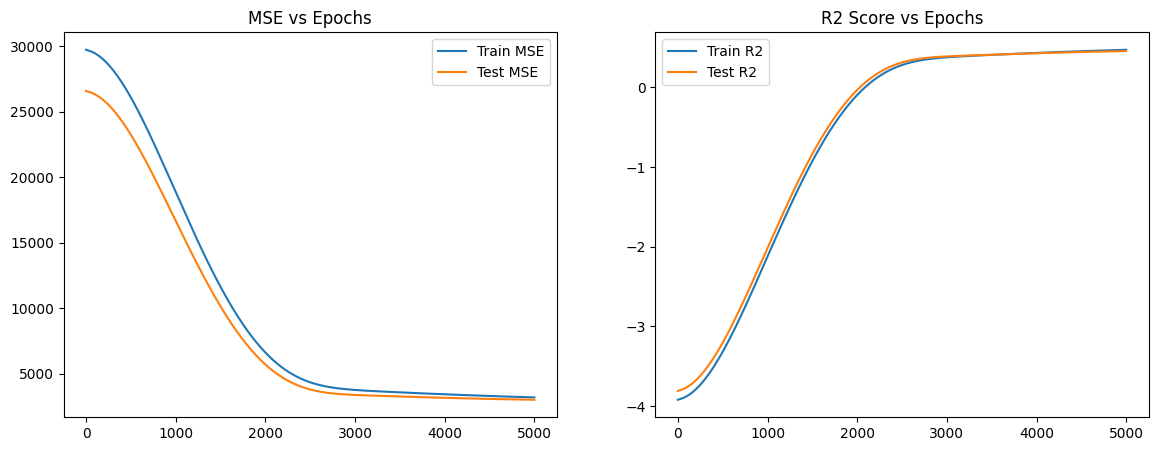

In [8]:
# Initialize the model with the best architecture (8,) from Task 2
model = MLPRegressor(hidden_layer_sizes=(8,), solver='adam', activation='relu', random_state = 42)

epochs = 5000
train_mse, test_mse, train_r2, test_r2 = [], [], [], []

# Train the model epoch by epoch using partial_fit
for epoch in range(epochs):
  model.partial_fit(X_train, y_train)
  p_train = model.predict(X_train)
  p_test = model.predict(X_test)

  # Calculate and store metrics for the current epoch
  train_mse.append(mean_squared_error(y_train, p_train))
  test_mse.append(mean_squared_error(y_test, p_test))
  train_r2.append(model.score(X_train, y_train))
  test_r2.append(model.score(X_test, y_test))

# Plotting the learning curves

# Plot 1: Mean Squared Error (MSE)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_mse, label='Train MSE')
ax1.plot(test_mse, label='Test MSE')
ax1.set_title('MSE vs Epochs')
ax1.legend()

# Plot 2: R2 Score
ax2.plot(train_r2, label='Train R2')
ax2.plot(test_r2, label='Test R2')
ax2.set_title('R2 Score vs Epochs')
ax2.legend()
plt.show()




** Conclusions**


**Two-stage Learning Dynamics:**

 The training process shows two distinct phases. For approximately the first 100 epochs, the error decreases slowly. After this stage, the learning rate significantly accelerates, resulting in a drop in MSE and a rise in the $R^2$ score.

**Stabilization and Early Overfitting:**

The curves begin to flatten around 2500–3000 epochs. After 3000 epochs, a discrepancy between metrics appears: while the Test MSE remains lower than the Train MSE, the Test $R^2$ starts to drop below the training value.

**Metric Discrepancy Interpretation:**

 The decrease in Test $R^2$ while MSE remains low indicates that the model is losing its ability to explain the variance in the test data, even though the absolute error stays small. This signals the onset of slight overfitting, where the network begins to over-optimize weights for specific correlations in the training set.

 **Convergence Observations:** The fact that the relationship between curves changes after 3000 epochs confirms that the 5000-epoch limit used in Task 2 made it possible to clearly see the point where the model starts to overfit and loses its stability.

### PCA and Network Performance.
Dimensionality reduction was performed on the diabetes dataset using PCA. The effect of this reduction on the neural network’s performance was then analyzed.

In [7]:
from sklearn.decomposition import PCA

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Standardize features (PCA is highly sensitive to the scale of the data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA
pca = PCA(n_components=2, random_state=42)
# Fit PCA and transform strictly on training data to prevent data leakage
X_train_pca = pca.fit_transform(X_train_scaled)
# Transform test data using the PCA projection learned from the training set
X_test_pca = pca.transform(X_test_scaled)

architectures = [
    (8,),
    (64,),
    (32, 32),
    (64, 32, 16),
    (16, 16, 16, 16, 16)
]

results = []

#  Train and evaluate models on the reduced dataset
for a in architectures:
  network = MLPRegressor(hidden_layer_sizes=a, solver='adam', max_iter=5000, activation='relu', random_state=42)
  network.fit(X_train_pca, y_train)
  pred = network.predict(X_test_pca)

  # Calculate metrics
  r2_train = network.score(X_train_pca, y_train)
  mse = mean_squared_error(y_test, pred)
  mape = mean_absolute_percentage_error(y_test, pred)
  r2 = network.score(X_test_pca, y_test)

  results.append((a, mse, mape, r2, pred))

  print(f"\nArchitecture: {a}")
  print(f"MSE: {mse:.4f} | MAPE: {mape:.4f} | R2: {r2:.4f} | R2 train: {r2_train:.4f}")



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(



Architecture: (8,)
MSE: 3775.9946 | MAPE: 0.4708 | R2: 0.3171 | R2 train: 0.3451

Architecture: (64,)
MSE: 3650.1735 | MAPE: 0.4548 | R2: 0.3399 | R2 train: 0.3689

Architecture: (32, 32)
MSE: 3732.9329 | MAPE: 0.4630 | R2: 0.3249 | R2 train: 0.3713

Architecture: (64, 32, 16)
MSE: 3633.0835 | MAPE: 0.4478 | R2: 0.3430 | R2 train: 0.3692

Architecture: (16, 16, 16, 16, 16)
MSE: 3760.1620 | MAPE: 0.4621 | R2: 0.3200 | R2 train: 0.3602


**Conclusions**

**Decrease in Goodness of Fit (Information Loss)**:

Comparing these results with Task 2 reveals a clear decline in the approximation quality. The best model without PCA achieved a coefficient of determination of $R^2 \approx 0.48$, whereas after dimensionality reduction, the highest score dropped to $R^2 \approx 0.34$. This is a direct consequence of compressing 10 features into just 2 principal components, which discarded too much of the essential variance from the original dataset. The reduced data lacks sufficient information to adequately model disease progression.

**Elimination of Overfitting:**

 In Task 2, deep architectures (e.g., 64, 32, 16) suffered from severe overfitting, resulting in negative $R^2$ scores on the test set. Applying PCA completely resolved this issue. For every evaluated network, the training and test scores are similar. This occurs because the reduced 2-dimensional input space drastically limits the network's capacity, preventing it from memorizing the noise in the training data.

**Similar Results Across Architectures:**

Because the models lack input information (underfitting), network complexity is no longer the main problem. As a result, all tested architectures achieved very similar scores. The (64, 32, 16) network provided the best fit, but the difference between this model and the simplest (8,) architecture is very small.